# Travelling transporter problem

## Introduction

For ride-hailing services and food delivery services like Uber and Takeaway.com, they have a set of trips from some starting location at a specific time (e.g. passenger pickup or restaurant), to some end point at a later time (e.g. passenger drop-off or customer location). A crucial problem they need to solve is to efficiently assign these trips to vehicles (or drivers). This has a direct and significant impact on their profit. Two potential goals would be:

- *Maximizing number of trips per vehicle:* If they are able to assign more trips to each vehicle, they need fewer vehicles to fulfil more (or all) trips. More trips per vehicle also means each vehicle (and also driver)'s time is utilized more efficiently.
- *Minimizing travel between trips:* We want to avoid travelling too far to get from the end location of one trip to the start location of the next trip. The more travel there is between trips, the less efficient vehicles and drivers are.

These goals are related: if there is less travel between trips, each vehicle is able to perform more trips.

In practice, it is likely better to try to calculate profit directly. Each trip likely has some given revenue, and there are known costs for vehicles or drivers and travel time, from which we're able to calculate profit. As a general solution, I'm not considering profit directly in this project.

Other problems could also be formulated through this trip-based lens. One example is delivering goods from some depots to other depots or to customers, although such problems may have more efficient solutions involving assigning trips to depots.

This is different from the well-known travelling salesperson problem, given that:

- We don't just need to visit specific locations, but travel from point A to point B.
- Trips have defined start times, rathe than being able to take place at any time.
- There are multiple vehicles, not just a single one.

## Problem description

For this project, I consider a more simplified version than what we'd likely see in the real world. For ride-hailing services for example, trips are commonly booked shortly before they take place, there usually is a variable amount of waiting time, and drivers start their day from a specific locations. I instead suppose we have all trip information upfront, each trip has a fixed start and end, and vehicles can start from anywhere. This could still be useful for getting a rough estimate of the minimum number of vehicles needed and the maximum potential profit, to see how much potential room there is to increase profit.

I set the number of vehicles upfront.

*Objective function:* For this problem, I try to maximize the number of trips per vehicle.

*Decision variables:* For each trip and each vehicle, consider whether that trip is performed by that vehicle.

*Constraints:*

- Each trip should only be performed by one vehicle.
- For any two trips on a vehicle, the later trip should be reachable from the earlier trip. That is to say: the start time of the later trip should not be before the end of the previous trip plus the travel time to the later trip's start location.


## Model formulation

I define variables as follows:

- $t_{ij}$: whether trip $i$ is performed by vehicle $j$ (0 or 1)
- $\overline{u_{ij}}$ is the set of trips incompatible with trip $ij$, with $u_{ijk}$ being whether trip $k$ is performed by vehicle $j$
- $s_i$: start time of trip $i$
- $e_i$: end time of trip $i$
- $d_{ij}$: travel time between trip $i$ and trip $j$
- $n^t$: the number of trips
- $n^v$: the number of vehicles
- $n^n_{ij}$: the number of trips incompatible with trip $i$ on vehicle $j$

Note that the start, end and travel times are vehicle-independent.

Assume trips are sorted by end time. This leads to a more compact formulation, since for any trips $i$ and $j$, if trip $j$ has a greater index, it cannot be before trip $i$, since it will have an end time that's at least as large as the end time of trip $i$. This can be represented as follows:

$$
e_i \le e_j \quad \forall i, j \in n^t : i \lt j
$$

So, to check that later trips are reachable from the current trip, we only need to consider greater trip indices.

Building on the above, we can say two trips $t_{ij}$ and $t_{kj}$ (with $k > i$) are incompatible if and only if the later trip's start isn't reachable from the earlier one's end. That is:

$$
t_{kj} \in \overline{u_{ij}} \iff e_i + d_{ik} \le s_k \quad \forall i, k \in n^t : i \lt k, \forall j = \left\{ 1, 2, \dots, n^v \right\}
$$

To set constraints for all pairs of trips that are incompatible, we could use a simple $t_{kj} + t_{ij} <= 1$, but this will cause an explosion of constraints. Below I use more compact constraints which combine a trip and all its incompatible trips into a single constraint.

$$
\begin{aligned}
\max \quad & \sum_{i=0}^{n^t} \sum_{j=0}^{n^v} t_{ij} \\
\text{s.t.} \quad & \sum_{j=0}^{n^v} t_{ij} \le 1 \quad \forall i = \left\{ 1, 2, \dots, n^t \right\} \\
& wt_{ij} + \sum_{j=0}^{w} u_{ijk} <= w \mid w = n^n_{ij} \quad \forall i = \left\{ 1, 2, \dots, n^t \right\}, j = \left\{ 1, 2, \dots, n^v \right\} \\
& t_{ij} \in \left\{ 0, 1 \right\} \quad \forall i = \left\{ 1, 2, \dots, n^t \right\}, j = \left\{ 1, 2, \dots, n^v \right\}
\end{aligned}
$$



## Method

The problem formulated above is a mixed-integer linear programming problem.

To generate an optimal solution, I used Python and the `milp` method from SciPy, which is an open-source library with various mathematical functions.

Larger-scale problems can't be solved using the above in a reasonable timeframe, given the complexity of the problem. To deal with this, I developed a greedy heuristic which goes through trips by sorted end time, and assigns each trip to the first vehicle where it fits (if any).

To get an upper bound of the objective value (which enables us to estimate the performance of the greedy heuristic), I generated the optimal solution for a single vehicle, and took that as the upper bound for the average number of trips per vehicle. A downside of this upper bound is that we expect the optimal objective value to decrease as the number of vehicles increases, but this upper bound stays constant.

## Data collection and/or generation

I used an existing dataset from [the OR dataset library](https://andreas-ernst.github.io/Mathprog-ORlib/), provided by Mohan Krishnamoorthy, Andreas Ernst and their collaborators. This provides collections of trips which is used directly for modelling.

The above dataset contains various problem instances of various sizes.

I used one of these instances for initial modelling (1500 trips), and additional ones for further evaluation.

## Results


In [50]:
import numpy as np
import pandas as pd
from scipy.optimize import Bounds, LinearConstraint, milp
from sklearn.manifold import MDS
import matplotlib
import matplotlib.pyplot as plt

filepath = "data/depot-scheduling/"
filename = filepath + "RN-8-1500-01.zip"

# Use read_csv instead of readline because the former works with zip
m, n, l = pd.read_csv(filename, nrows=1, sep=" ", header=None).values[0]

# with open(filename, "r") as file:
#     m, n, l = map(int, file.readline().split())
#     max_vehicles_in_depot = [int(x) for x in file.readline().split()]

trips = pd.read_csv(filename, skiprows=2, nrows=n, sep=" ", names=["start_location", "start_time", "end_location", "end_time"])
travel_times = pd.read_csv(filename, skiprows=2 + n, nrows=l, sep=" ", header=None).dropna(axis="columns")

print("Trips:")
display(trips)
print("Travel times:")
display(travel_times)

# Set default figure size
matplotlib.rcParams['figure.figsize'] = (4, 3)


Trips:


,start_location,start_time,end_location,end_time
0,204,1173,204,1427
1,529,995,529,1295
2,234,759,459,783
3,504,420,504,707
4,360,1024,360,1299
...,...,...,...,...
1495,392,1140,392,1371
1496,298,651,298,851
1497,291,424,291,689
1498,409,575,313,616


Travel times:


,0,1,2,3,4,5,6,7,8,9,...,659,660,661,662,663,664,665,666,667,668
0,0,85,60,60,37,71,25,71,23,61,...,82,24,16,62,60,70,44,56,62,24
1,85,0,60,60,50,20,64,15,64,42,...,4,68,75,38,58,19,57,41,29,68
2,60,60,0,85,39,42,39,50,53,71,...,58,38,46,68,83,57,19,65,59,38
3,60,60,85,0,48,61,56,53,42,20,...,59,62,61,24,4,44,70,23,34,61
4,37,50,39,48,0,34,15,35,19,37,...,46,20,26,36,46,35,22,31,31,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,70,19,57,44,35,20,50,10,47,25,...,16,55,60,21,41,0,48,23,11,54
665,44,57,19,70,22,38,21,44,35,57,...,54,21,29,55,67,48,0,51,48,21
666,56,41,65,23,31,38,43,31,33,7,...,38,49,51,7,20,23,51,0,13,48
667,62,29,59,34,31,27,45,19,39,15,...,26,51,55,12,31,11,48,13,0,50


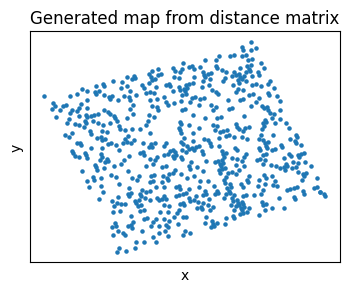

In [198]:
# Fit MDS to obtain 2D coordinates
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, n_init=1)
coords = mds.fit_transform(travel_times)

# Plot trips and depots in different colours
# plt.scatter(coords[m:, 0], coords[m:, 1], label="Trip", s=5)
# plt.scatter(coords[:m, 0], coords[:m, 1], label="Depot")
# plt.legend()

# Plot points
plt.scatter(coords[:, 0], coords[:, 1], s=5)

plt.xlabel("x")
plt.ylabel("y")
plt.xticks([])
plt.yticks([])
plt.title("Generated map from distance matrix")
plt.show()

Here is a small sample of trips in our example instance.

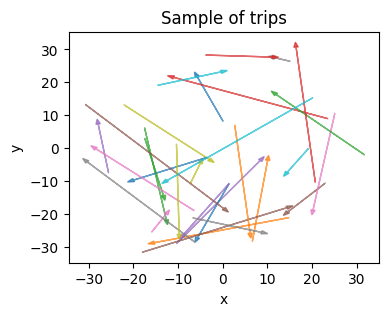

In [ ]:
trips_new = pd.DataFrame()
trips_new[["start_x", "start_y"]] = pd.DataFrame(trips["start_location"].map(lambda id: coords[id]).to_list())
trips_new[["end_x", "end_y"]] = pd.DataFrame(trips["end_location"].map(lambda id: coords[id]).to_list())
trips_new = trips_new.iloc[0:30]

from itertools import cycle

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = cycle(colors)

for _, row in trips_new.iterrows():
    # Plot lines instead of arrows
    # plt.plot(
    #     [row.start_x, row.end_x],
    #     [row.start_y, row.end_y],
    # )

    plt.arrow(
        row["start_x"], row["start_y"],
        row["end_x"] - row["start_x"],
        row["end_y"] - row["start_y"],
        head_width=1,
        length_includes_head=True,
        alpha=0.7,
        color=next(color_cycle)
    )


plt.title("Sample of trips")
plt.xlabel("x")
plt.ylabel("y")
pass


In [32]:
trip_count = len(trips)
trips = trips.sort_values("end_time")
trips = trips.reset_index(names="id")
trips

,id,start_location,start_time,end_location,end_time
0,1101,392,425,550,455
1,1478,596,422,629,461
2,805,538,421,96,465
3,1142,522,424,159,468
4,403,481,423,118,468
...,...,...,...,...,...
1495,372,530,1165,530,1465
1496,1422,500,1190,500,1467
1497,773,66,1196,66,1472
1498,1351,459,1199,459,1475


In [5]:
def run_solver(vehicle_count=1):
    constraints = []

    # Mark trips as incompatible if there isn't enough time after one ends to reach the other
    for vehicle in range(vehicle_count):
        for t1_id, t1_row in trips.iterrows():
            df = trips.iloc[t1_id+1:]
            df_start = df.start_time - travel_times[t1_row.end_location][df.start_location].values
            df_start = df_start[df_start < t1_row.end_time]
            A = np.zeros(trip_count * vehicle_count)
            A[vehicle * trip_count + df.id[df_start.index]] = 1
            A[vehicle * trip_count + t1_row.id] = len(df_start)
            constraints.append(LinearConstraint(A, ub=len(df_start)))

    # Make sure a trip is on at most 1 vehicle
    if vehicle_count > 1:
        for trip in range(trip_count):
            A = np.zeros(trip_count * vehicle_count)
            for vehicle in range(vehicle_count):
                A[vehicle * trip_count + trip] = 1
            constraints.append(LinearConstraint(A, ub=1))

    bounds = [[], []]

    # Make sure each trip is in {0, 1}
    for vehicle in range(vehicle_count):
        for trip in range(trip_count):
            bounds[0].append(0)
            bounds[1].append(1)

    # Maximise number of trips
    # Flip coef sign to turn maximization problem into minimization problem
    coef = -np.ones_like(trips.index)

    # Set all variables to be integers
    integrality = np.ones_like(coef)

    # Run solver and return solution
    return milp(c=coef, constraints=constraints, integrality=integrality, bounds=Bounds(*bounds), options={"time_limit": 10*60})


In [ ]:
res = run_solver()
res

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -15.000000000000098
              x: [ 0.000e+00  0.000e+00 ...  1.131e-14  0.000e+00]
 mip_node_count: 451
 mip_dual_bound: -15.000000000000098
        mip_gap: 0.0

In [29]:
def plot_trips(trips_df):
    plt.figure(figsize=(4, 3))
    trips_df = trips_df.sort_values("end_time")
    trips_tmp = pd.DataFrame()
    trips_tmp[["start_x", "start_y"]] = pd.DataFrame(trips_df["start_location"].map(lambda id: coords[id]).to_list())
    trips_tmp[["end_x", "end_y"]] = pd.DataFrame(trips_df["end_location"].map(lambda id: coords[id]).to_list())

    # Plot trip lines (dashed)
    for _, row in trips_tmp.iterrows():
        plt.plot(
            [row.start_x, row.end_x],
            [row.start_y, row.end_y],
            color="black",
            linestyle='dashed',
            marker="o",
        )

    for i, trip in trips_tmp.iterrows():
        if (trip.start_x, trip.start_y) == (trip.end_x, trip.end_y):
            plt.text(trip.start_x + 1, trip.start_y + 1, f"{i}")
        else:
            plt.text(trip.start_x + 1, trip.start_y + 1, f"{i}s")
            plt.text(trip.end_x + 1, trip.end_y + 1, f"{i}e")

    # Plot travel between trips (solid)
    for _, row in trips_tmp.join(trips_tmp.shift(-1), rsuffix="_next").iterrows():
        plt.plot(
            [row.end_x, row.start_x_next],
            [row.end_y, row.start_y_next],
            color="black",
            marker="o",
        )

    # Remove x and y ticks and tick labels
    plt.xticks([])
    plt.yticks([])

    plt.xlabel("x")
    plt.ylabel("y")

def plot_timeline(trips_df, vehicle=None, ax=None, display_travel_between=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 0.25))
        plt.title("Selected trips timeline")

    # suffix = "" if vehicle is None else f", vehicle {vehicle}"
    # label = "Trips" if vehicle is None else f"Vehicle {vehicle}"
    label = "Trips" if vehicle is None else str(vehicle)

    # if vehicle is None:
    # Hide y-axis labels (remove ticks)
    plt.yticks([])
    # Hide y-axis labels (keep ticks)
    # plt.gca().set_yticklabels([])

    trips_df = trips_df.sort_values("end_time")
    for _, row in trips_df.join(trips_df.shift(-1), rsuffix="_next").iterrows():
        ax.barh(
            y=label,
            width=(row["end_time"] - row["start_time"]),
            left=row["start_time"],
            height=0.4,
            color="skyblue",
            edgecolor="black"
        )

        if display_travel_between and vehicle is None:
            ax.barh(
                y="Travel between trips", # + suffix,
                width=(row["start_time_next"] - row["end_time"]),
                left=row["end_time"],
                height=0.4,
                color="darkblue",
                edgecolor="black"
            )

    # Remove x ticks and tick labels
    plt.xticks([])
    plt.xlabel("Time")


For 1 vehicle, the optimal route contains 15 trips. Here is a graphical plot of the route, along with a timeline of the trips on that route.

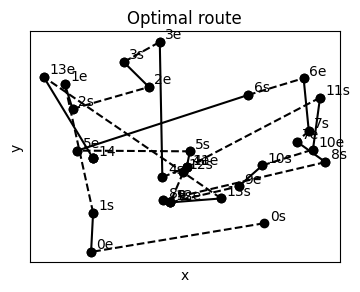

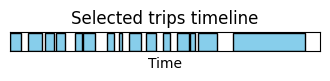

In [235]:
# Select optimal trips, which have res[trip.id] == 1 (and check `> 0.999` because of floating point imprecision)
trips_optimal = trips.sort_values("id")[res.x > 0.999].sort_values("end_time")
plot_trips(trips_optimal)
plt.title("Optimal route")
plot_timeline(trips_optimal)


In [42]:
trips_optimal

,id,start_location,start_time,end_location,end_time
1,1478,596,422,629,461
94,1084,233,483,419,532
147,1153,480,545,60,573
202,525,300,583,539,612
301,487,503,649,242,670
390,80,114,676,443,718
502,2,234,759,459,783
557,1183,444,800,245,812
664,567,239,836,277,877
741,515,290,892,546,928


By comparison, our greedy algorithm contains 14 trips (optimality gap 6.67%). Here is a graphical plot and timeline of the route.

In [218]:
trips_greedy = []
for i, trip in trips.iterrows():
    if trips_greedy:
        last = trips_greedy[-1]
        if trip.start_time < last.end_time + travel_times[last.end_location][trip.start_location]:
            continue
    trips_greedy.append(trip)

trips_greedy = pd.DataFrame(trips_greedy)
print("Length for greedy scheduling: ", len(trips_greedy))


Length for greedy scheduling:  14


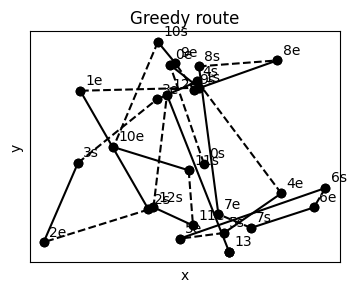

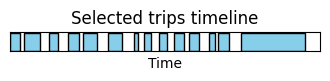

In [236]:
plot_trips(trips_greedy)
plt.title("Greedy route")
plot_timeline(trips_greedy)


We can run our greedy algorithm for more vehicles, showing that the number of trips per vehicle decreases as the number of vehicles increases. This is expected, both because more vehicles with the same number of trips means the optimal solution is worse, and because our algorithm is suboptimal.

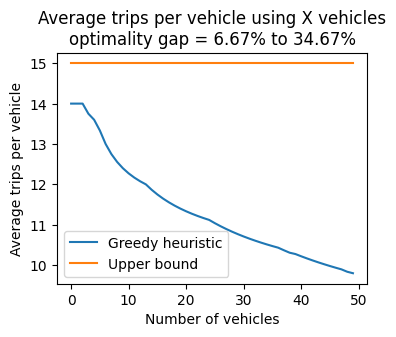

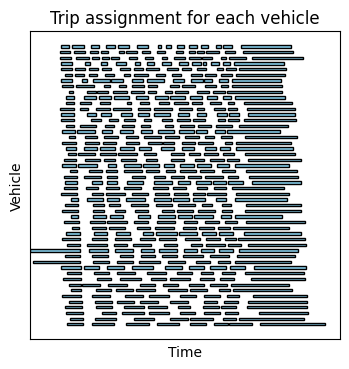

In [33]:
vehicle_count = 50
trips_greedy = [[] for _ in range(vehicle_count)]
for i, trip in trips.iterrows():
    for vehicle in range(vehicle_count):
        if trips_greedy[vehicle]:
            last = trips_greedy[vehicle][-1]
            if trip.start_time < last.end_time + travel_times[last.end_location][trip.start_location]:
                continue
        trips_greedy[vehicle].append(trip)
        break

upper_bound = 15
# upper_bound = len(trips_optimal)
plt.figure(figsize=(4, 3))
greedy_trip_count = np.cumsum([len(trips_greedy[v]) for v in range(vehicle_count)]) / np.arange(1, vehicle_count+1)
plt.plot(greedy_trip_count, label="Greedy heuristic")
plt.plot([upper_bound for _ in range(vehicle_count)], label="Upper bound")
plt.title(f"Average trips per vehicle using X vehicles\noptimality gap = {(upper_bound - greedy_trip_count[0]) / upper_bound:.2%} to {(upper_bound - greedy_trip_count[-1]) / upper_bound:.2%}")
plt.xlabel("Number of vehicles")
plt.ylabel("Average trips per vehicle")
plt.legend()

fig, ax = plt.subplots(figsize=(4, 4))
plt.title("Trip assignment for each vehicle")
plt.ylabel("Vehicle")

for vehicle in reversed(range(vehicle_count)):
    trips_df = pd.DataFrame(trips_greedy[vehicle])
    plot_timeline(trips_df, vehicle, ax)


In [217]:
# Potential lower bound - greedy interval scheduling: ignore travel time
trips_interval = []
for i, trip in trips.iterrows():
    if trips_interval:
        last = trips_interval[-1]
        if trip.start_time < last.end_time:
            continue
    trips_interval.append(trip)

trips_interval = pd.DataFrame(trips_interval)
print("Length for greedy interval scheduling: ", len(trips_interval))


Length for greedy interval scheduling:  22


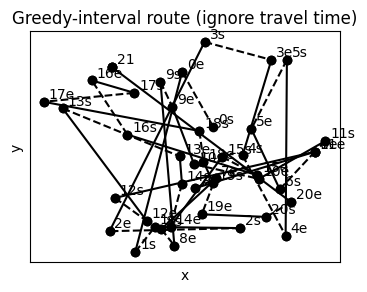

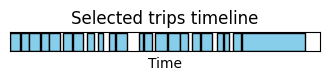

In [239]:
plot_trips(trips_interval)
plt.title("Greedy-interval route (ignore travel time)")
plot_timeline(trips_interval)


In [ ]:
res2 = run_solver(vehicle_count=2)
res2

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -30.0
              x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
 mip_node_count: 2025
 mip_dual_bound: -30.0
        mip_gap: 0.0

I also ran the integer programming solver for 2 and 3 vehicles. 2 vehicles, also resulted in 15 trips per vehicle. 3 vehicles resulted in 14.33 trips per vehicle. Although the latter timed out after running for 30 minutes. This is somewhat consistent with the greedy algorithm, which has 14 trips per vehicle for 1-3 vehicles.

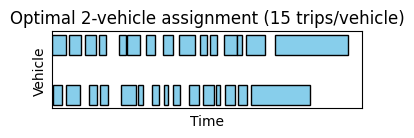

In [244]:
vehicle_count = 2
trips_optimal2 = []
for vehicle in reversed(range(vehicle_count)):
    trips_optimal2.append(trips.sort_values("id")[res2.x[vehicle * 1500 : (vehicle + 1) * 1500] > 0.999].sort_values("end_time"))

fig, ax = plt.subplots(figsize=(4, 1))
plt.title(f"Optimal {vehicle_count}-vehicle assignment ({-res2.fun / vehicle_count:g} trips/vehicle)")
plt.xlabel("Time")
plt.ylabel("Vehicle")

for vehicle in reversed(range(vehicle_count)):
    trips_df = pd.DataFrame(trips_optimal2[vehicle])
    plot_timeline(trips_df, vehicle, ax)


In [ ]:
res3 = run_solver(vehicle_count=3)
res3

        message: Time limit reached. (HiGHS Status 13: Time limit reached)
        success: False
         status: 1
            fun: -43.0
              x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
 mip_node_count: 1216
 mip_dual_bound: -65.0
        mip_gap: 0.5116279069767442

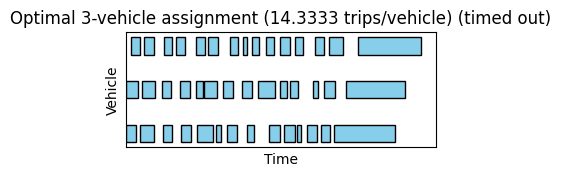

In [256]:
vehicle_count = 3
trips_optimal3 = []
for vehicle in reversed(range(vehicle_count)):
    trips_optimal3.append(trips.sort_values("id")[res3.x[vehicle * 1500 : (vehicle + 1) * 1500] > 0.999].sort_values("end_time"))

fig, ax = plt.subplots(figsize=(4, 1.5))
plt.title(f"Optimal {vehicle_count}-vehicle assignment ({-res3.fun / vehicle_count:g} trips/vehicle) (timed out)")
plt.xlabel("Time")
plt.ylabel("Vehicle")

for vehicle in reversed(range(vehicle_count)):
    trips_df = pd.DataFrame(trips_optimal3[vehicle])
    plot_timeline(trips_df, vehicle, ax)


In [ ]:
reses = []
greedy_trip_counts = []

for filename in [
    "RN-8-1500-01.zip",
    "RN-8-2000-02.zip",
    "RN-12-2500-03.zip",
    "RN-16-3000-04.zip",
]:
    filename = filepath + filename

    m, n, l = pd.read_csv(filename, nrows=1, sep=" ", header=None).values[0]
    trips = pd.read_csv(filename, skiprows=2, nrows=n, sep=" ", names=["start_location", "start_time", "end_location", "end_time"])
    travel_times = pd.read_csv(filename, skiprows=2 + n, nrows=l, sep=" ", header=None).dropna(axis="columns")

    # trip_count = len(trips)

    # Select the earliest 1500 values
    trip_count = 1500
    trips = trips.sort_values("end_time")
    trips = trips[:1500]

    # Remove gaps between index values
    trips = trips.sort_index().reset_index(drop=True)

    trips = trips.sort_values("end_time")
    trips = trips.reset_index(names="id")

    reses.append(run_solver())

    vehicle_count = 50
    trips_greedy = [[] for _ in range(vehicle_count)]
    for i, trip in trips.iterrows():
        for vehicle in range(vehicle_count):
            if trips_greedy[vehicle]:
                last = trips_greedy[vehicle][-1]
                if trip.start_time < last.end_time + travel_times[last.end_location][trip.start_location]:
                    continue
            trips_greedy[vehicle].append(trip)
            break

    greedy_trip_counts.append(np.cumsum([len(trips_greedy[v]) for v in range(vehicle_count)]) / np.arange(1, vehicle_count+1))


In [12]:
print("Optimal trips per vehicle:", ", ".join(str(round(-r.fun)) for r in reses))

Optimal trips per vehicle: 15, 15, 12, 10


### Other instances

I also ran the greedy and optimal 1-vehicle algorithms on other instances from the dataset, finding similar results.

Each instance has 1500 trips, and for each subsequent instance, those trips are taken from a shorter period of time. This helps to show how the algorithm deals with more and less dense data.

The optimality gap ranges from 6.67% to 16.67% for 1 vehicle, up to 28.4% to 38.8% for 50 vehicles, with a relatively constant decline in performance as the number of vehicles increases.

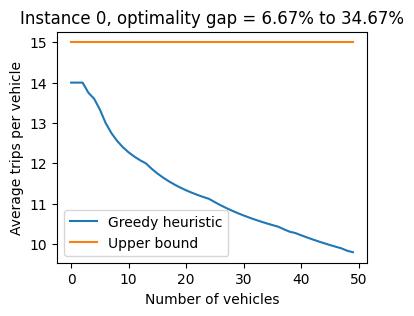

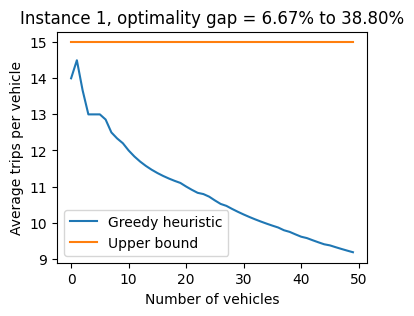

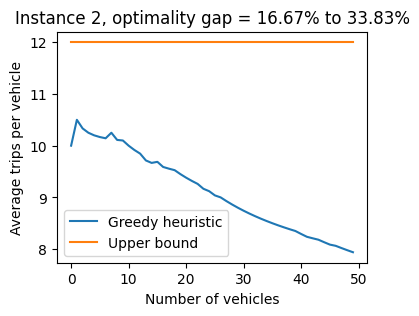

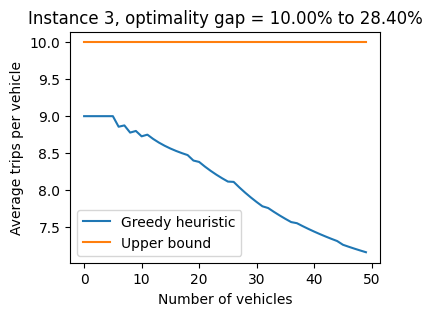

In [24]:
for i, greedy_trip_count in enumerate(greedy_trip_counts):
    upper_bound = -reses[i].fun
    plt.figure(figsize=(4, 3))
    plt.plot(greedy_trip_count, label="Greedy heuristic")
    plt.plot([upper_bound for _ in range(vehicle_count)], label="Upper bound")
    plt.title(f"Instance {i}, optimality gap = {(upper_bound - greedy_trip_count[0]) / upper_bound:.2%} to {(upper_bound - greedy_trip_count[-1]) / upper_bound:.2%}")
    plt.xlabel("Number of vehicles")
    plt.ylabel("Average trips per vehicle")
    plt.legend()


### Conclusion

The results show that the greedy heuristic produces a reasonable solution. This could be used to get a rough estimate of the optimal solution for real-world applications.

Further work could involve processing trips as they come in, varying weighting time rather than fixing trip time, and possibly having some predefined driver start locations. This could better deal with the real-world constraints of use cases like ride-hailing.

One could also try to improve the upper bound to get a better estimate of how well the greedy heuristic performs as the number of vehicles increases.
